Лабораторная работа 3

Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

Датасет:

Набор содержит данные по использованию смартфонов различными людьми с целевым параметром - смартфонозависимость
https://www.kaggle.com/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction

Количество записей 7500

Колонки данных:
-Идентификатор записи
-Идентификатор персоны
-Возраст
-Пол
-Статистика использования телефона
-Уровень стресса 
-Влияние на учебу
-Смартфонозависимость


In [224]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [225]:
data = pd.read_csv('SmU.csv', sep=",")

In [226]:
# Первые 5 строк датасета
data.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [227]:
data.drop(columns=['transaction_id','user_id','addiction_level', 'gender','stress_level','academic_work_impact'],inplace=True)

In [228]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   daily_screen_time_hours  7500 non-null   float64
 2   social_media_hours       7500 non-null   float64
 3   gaming_hours             7500 non-null   float64
 4   work_study_hours         7500 non-null   float64
 5   sleep_hours              7500 non-null   float64
 6   notifications_per_day    7500 non-null   int64  
 7   app_opens_per_day        7500 non-null   int64  
 8   weekend_screen_time      7500 non-null   float64
 9   addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(4)
memory usage: 586.1 KB


In [229]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


Разделение выборки на обучающую и тестовую

In [230]:
X=data.drop(columns='addicted_label')

In [231]:
Y=data['addicted_label']

In [232]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y , test_size = 0.3, random_state= 1)

In [233]:
# Размер обучающей выборки
X_train.shape, Y_train.shape

((5250, 9), (5250,))

In [234]:
# Размер тестовой выборки
X_test.shape, Y_test.shape

((2250, 9), (2250,))

In [235]:
np.unique(Y_train)

array([0, 1])

In [236]:
np.unique(Y_test)

array([0, 1])

In [237]:
def class_proportions(array: np.ndarray) -> Dict[int, Tuple[int, float]]:
    """
    Вычисляет пропорции классов
    array - массив, содержащий метки классов
    """
    # Получение меток классов и количества меток каждого класса 
    labels, counts = np.unique(array, return_counts=True)
    # Превращаем количество меток в процент их встречаемости
    # делим количество меток каждого класса на общее количество меток
    counts_perc = counts/array.size
    # Теперь sum(counts_perc)==1.0
    # Создаем результирующий словарь,
    # ключом словаря явлется метка класса, 
    # а значением словаря процент встречаемости метки
    res = dict()
    for label, count2 in zip(labels, zip(counts, counts_perc)):
        res[label] = count2
    return res

def print_class_proportions(array: np.ndarray):
    """
    Вывод пропорций классов
    """
    proportions = class_proportions(array)
    if len(proportions)>0:
        print('Метка \t Количество \t Процент встречаемости')
    for i in proportions:
        val, val_perc = proportions[i]
        val_perc_100 = round(val_perc * 100, 2)
        print('{} \t {} \t \t {}%'.format(i, val, val_perc_100))

Построение базовые модели на основе метода ближайших соседей

In [238]:
# 2 ближайших соседа
cl1_1 = KNeighborsClassifier(n_neighbors=2)
cl1_1.fit(X_train, Y_train)
target1_1 = cl1_1.predict(X_test)
len(target1_1), target1_1

(2250, array([1, 1, 0, ..., 0, 0, 1], shape=(2250,)))

In [239]:
# 10 ближайших соседей
cl1_2 = KNeighborsClassifier(n_neighbors=10)
cl1_2.fit(X_train, Y_train)
target1_2 = cl1_2.predict(X_test)
len(target1_2), target1_2

(2250, array([0, 1, 0, ..., 0, 0, 1], shape=(2250,)))

Метрики качества классификации
1) Accuracy
Метрика вычисляет процент (долю в диапазоне от 0 до 1) правильно определенных классов.

In [240]:
# Y_test - эталонное значение классов из исходной (тестовой) выборки
# target* - предсказанное значение классов

# 2 ближайших соседа
accuracy_score(Y_test, target1_1)

0.6986666666666667

In [241]:
# 10 ближайших соседей
accuracy_score(Y_test, target1_2)

0.772

In [242]:
def accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса, 
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame 
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют 
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values, 
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray, 
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [243]:
# 2 ближайших соседа
print_accuracy_score_for_classes(Y_test, target1_1)

Метка 	 Accuracy
0 	 0.7507987220447284
1 	 0.6785714285714286


In [244]:
# 10 ближайших соседей
print_accuracy_score_for_classes(Y_test, target1_2)

Метка 	 Accuracy
0 	 0.4952076677316294
1 	 0.8786945812807881


In [245]:
balanced_accuracy_score(Y_test, target1_1)

0.7146850753080785

In [246]:
balanced_accuracy_score(Y_test, target1_2)

0.6869511245062088

2) Матрица ошибок или Confusion Matrix
Количество верно и ошибочно классифицированных данных, представленное в виде матрицы.

In [247]:
tn, fp, fn, tp = confusion_matrix(Y_test, target1_1).ravel()
tn, fp, fn, tp

(np.int64(470), np.int64(156), np.int64(522), np.int64(1102))

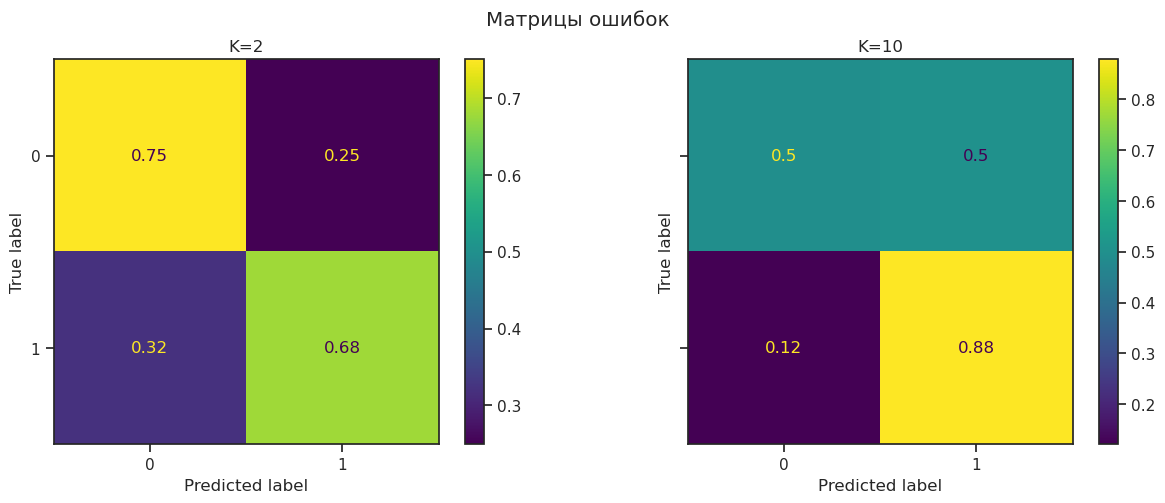

In [248]:
fig, ax = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(15,5))
ConfusionMatrixDisplay.from_estimator(cl1_1, X_test, Y_test,normalize='true', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(cl1_2, X_test, Y_test,normalize='true', ax=ax[1])
fig.suptitle('Матрицы ошибок')
ax[0].title.set_text('K=2')
ax[1].title.set_text('K=10')

3) Precision, recall и F-мера

In [249]:
# По умолчанию метрики считаются для 1 класса бинарной классификации
# Для 2 ближайших соседей
precision_score(Y_test, target1_1), recall_score(Y_test, target1_1)

(0.875993640699523, 0.6785714285714286)

In [250]:
# Для 10 ближайших соседей
precision_score(Y_test, target1_2), recall_score(Y_test, target1_2)

(0.8187033849684452, 0.8786945812807881)

In [251]:
# Для 2 ближайших соседей
f1_score(Y_test, target1_1)

0.7647467036780013

In [252]:
# Для 10 ближайших соседей
f1_score(Y_test, target1_2)

0.8476388476388477

In [253]:
# Для 2 ближайших соседей
classification_report(Y_test, target1_1, output_dict=True)

{'0': {'precision': 0.4737903225806452,
  'recall': 0.7507987220447284,
  'f1-score': 0.580964153275649,
  'support': 626.0},
 '1': {'precision': 0.875993640699523,
  'recall': 0.6785714285714286,
  'f1-score': 0.7647467036780013,
  'support': 1624.0},
 'accuracy': 0.6986666666666667,
 'macro avg': {'precision': 0.6748919816400841,
  'recall': 0.7146850753080785,
  'f1-score': 0.6728554284768251,
  'support': 2250.0},
 'weighted avg': {'precision': 0.7640917397473375,
  'recall': 0.6986666666666667,
  'f1-score': 0.7136143140993914,
  'support': 2250.0}}

In [254]:
# Для 10 ближайших соседей
classification_report(Y_test, target1_2, output_dict=True)

{'0': {'precision': 0.611439842209073,
  'recall': 0.4952076677316294,
  'f1-score': 0.5472197705207414,
  'support': 626.0},
 '1': {'precision': 0.8187033849684452,
  'recall': 0.8786945812807881,
  'f1-score': 0.8476388476388477,
  'support': 1624.0},
 'accuracy': 0.772,
 'macro avg': {'precision': 0.7150716135887591,
  'recall': 0.6869511245062088,
  'f1-score': 0.6974293090797945,
  'support': 2250.0},
 'weighted avg': {'precision': 0.7610380615162822,
  'recall': 0.772,
  'f1-score': 0.764055584405099,
  'support': 2250.0}}

4) ROC-кривая и ROC AUC

In [255]:
# 2 ближайших соседа
bin_cl1_1 = KNeighborsClassifier(n_neighbors=2)
bin_cl1_1.fit(X_train, Y_train)
# предскажем метки классов
bin_cl1_1.predict(X_test)

array([1, 1, 0, ..., 0, 0, 1], shape=(2250,))

In [256]:
# предскажем вероятности классов
proba_target1_1 = bin_cl1_1.predict_proba(X_test)
len(proba_target1_1), proba_target1_1

(2250,
 array([[0. , 1. ],
        [0. , 1. ],
        [0.5, 0.5],
        ...,
        [1. , 0. ],
        [0.5, 0.5],
        [0. , 1. ]], shape=(2250, 2)))

In [257]:
# вероятность единичного (истинного) класса
true_proba_target1_1 = proba_target1_1[:,1]
true_proba_target1_1

array([1. , 1. , 0.5, ..., 0. , 0.5, 1. ], shape=(2250,))

In [258]:
fpr, tpr, thresholds = roc_curve(Y_test, true_proba_target1_1, 
                                 pos_label=1)
fpr, tpr, thresholds

(array([0.        , 0.24920128, 0.72364217, 1.        ]),
 array([0.        , 0.67857143, 0.93657635, 1.        ]),
 array([inf, 1. , 0.5, 0. ]))

In [259]:
# Отрисовка ROC-кривой
def draw_roc_curve(y_true, y_score, pos_label, average):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, 
                                     pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_value)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")
    plt.show()

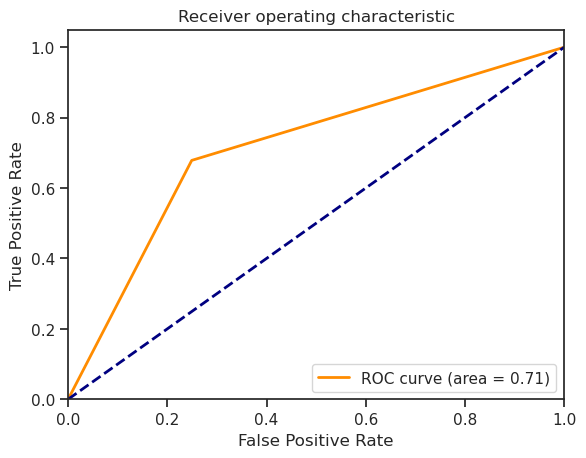

In [260]:
# Для 2 ближайших соседей
draw_roc_curve(Y_test, target1_1, pos_label=1, average='micro')

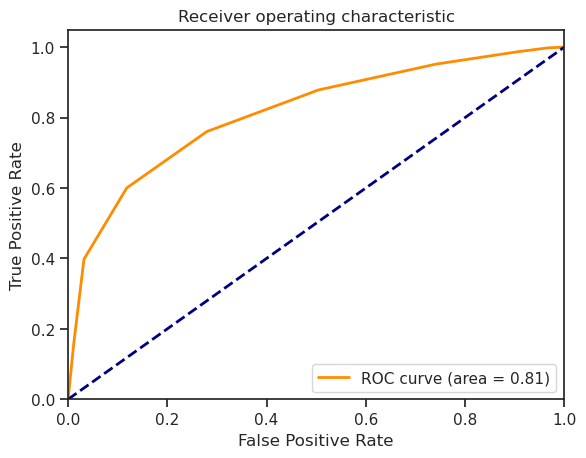

In [261]:
# Для 10 ближайших соседей
bin_cl1_2 = KNeighborsClassifier(n_neighbors=10)
bin_cl1_2.fit(X_train, Y_train)
proba_target2_1 = bin_cl1_2.predict_proba(X_test)
true_proba_target2_1 = proba_target2_1[:,1]
roc_curve_k10_res = roc_curve(Y_test, true_proba_target2_1, pos_label=1)
draw_roc_curve(Y_test, true_proba_target2_1, pos_label=1, average='micro')

Оптимизация гиперпараметров
Grid Search (решетчатый поиск)

In [262]:
n_range = np.array(range(5,55,5))
tuned_parameters = [{'n_neighbors': n_range}]
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_gs.fit(X_train, Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': array([ 5, 10..., 40, 45, 50])}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(5)


In [263]:
clf_gs.best_params_

{'n_neighbors': np.int64(5)}

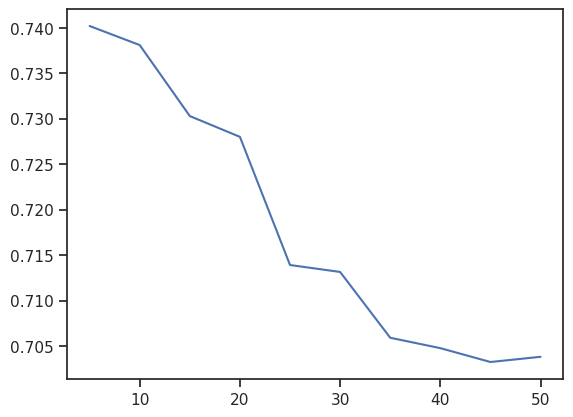

In [264]:
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

In [265]:
# 5.Обучение модели и оценка качества с учетом подобранных гиперпараметров
clf_gs.best_estimator_.fit(X_train, Y_train)
target2_0 = clf_gs.best_estimator_.predict(X_train)
target2_1 = clf_gs.best_estimator_.predict(X_test)

In [266]:
# Новое качество модели
accuracy_score(Y_train, target2_0), accuracy_score(Y_test, target2_1)

(0.8411428571428572, 0.7675555555555555)

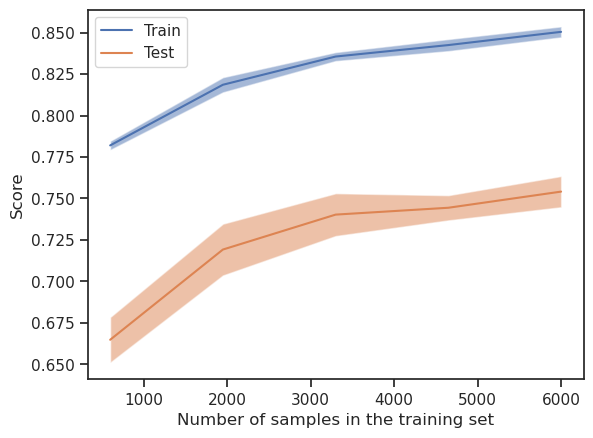

In [267]:
# 6.Построение кривых обучения и валидации
LearningCurveDisplay.from_estimator(clf_gs.best_estimator_, X, Y)

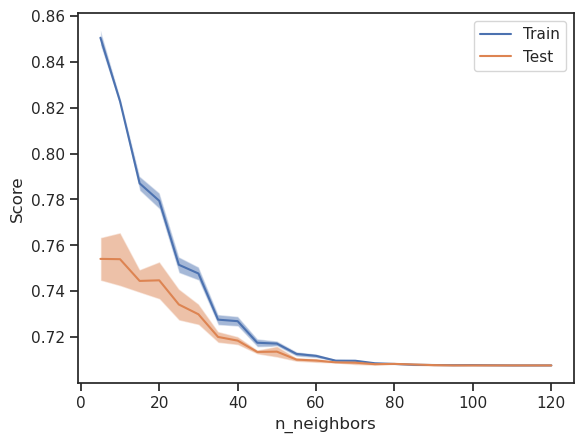

In [268]:
n_range2 = np.array(range(5,125,5))
ValidationCurveDisplay.from_estimator(clf_gs.best_estimator_, X, Y, param_name='n_neighbors', param_range=n_range2,)

Кросс-валидация

In [269]:
scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), 
                         X, Y, cv=3)
scores

array([0.7492, 0.7548, 0.7616])

In [270]:
# Усредненное значение метрики accuracy для 3 фолдов
np.mean(scores)

np.float64(0.7552)

In [271]:
# использование метрики f1
# https://scikit-learn.org/stable/modules/model_evaluation.html
scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), 
                         X, Y, cv=3,
                        scoring='f1_weighted')
scores, np.mean(scores)

(array([0.73595279, 0.74540628, 0.74936999]), np.float64(0.7435763530108233))

In [272]:
scoring = {'precision': 'precision_weighted', 
           'recall': 'recall_weighted',
           'f1': 'f1_weighted'}
scores = cross_validate(KNeighborsClassifier(n_neighbors=5), 
                        X, Y, scoring=scoring, 
                        cv=3, return_train_score=True)
scores

{'fit_time': array([0.00592256, 0.00420713, 0.00413585]),
 'score_time': array([0.01287341, 0.0115428 , 0.01002645]),
 'test_precision': array([0.73378455, 0.74252491, 0.74802836]),
 'train_precision': array([0.83903678, 0.84204457, 0.83994294]),
 'test_recall': array([0.7492, 0.7548, 0.7616]),
 'train_recall': array([0.8432, 0.846 , 0.8438]),
 'test_f1': array([0.73595279, 0.74540628, 0.74936999]),
 'train_f1': array([0.83796462, 0.84094613, 0.83774591])}